✅ Data successfully prepared for analysis.
📊 Model Performance (R2 Score): 0.9429


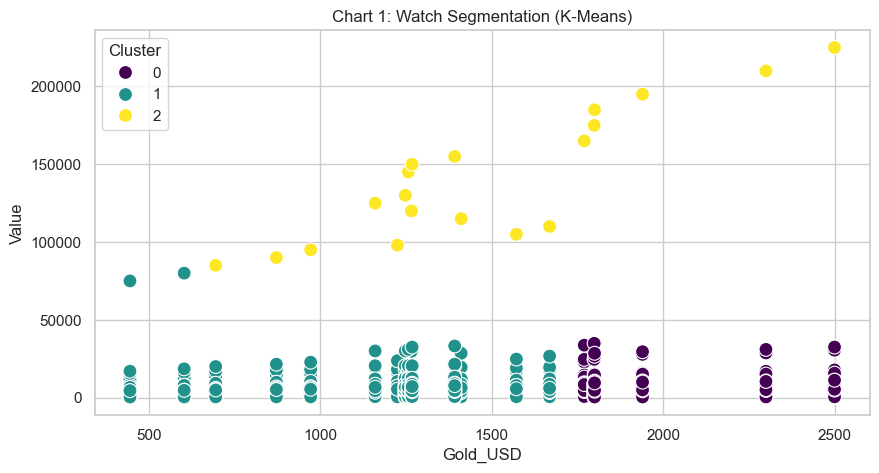

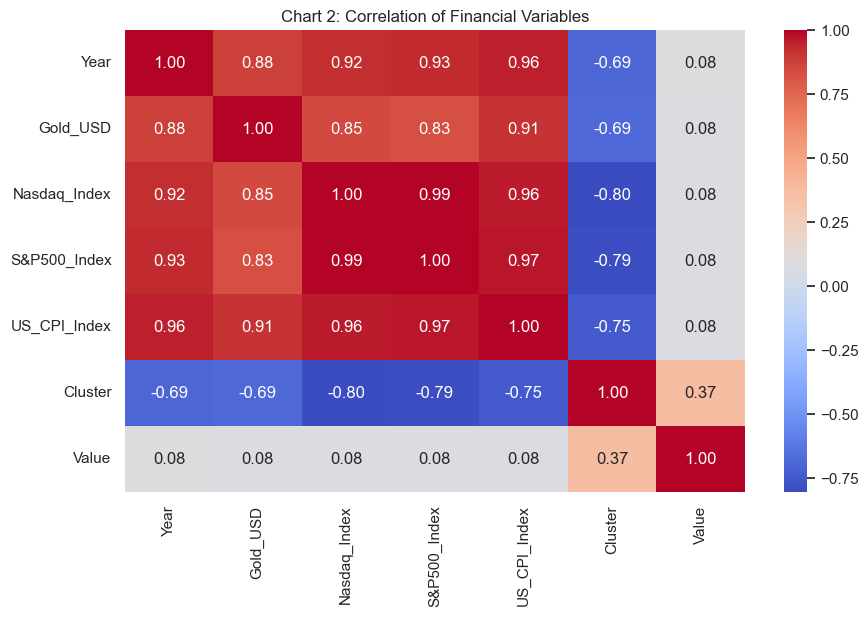

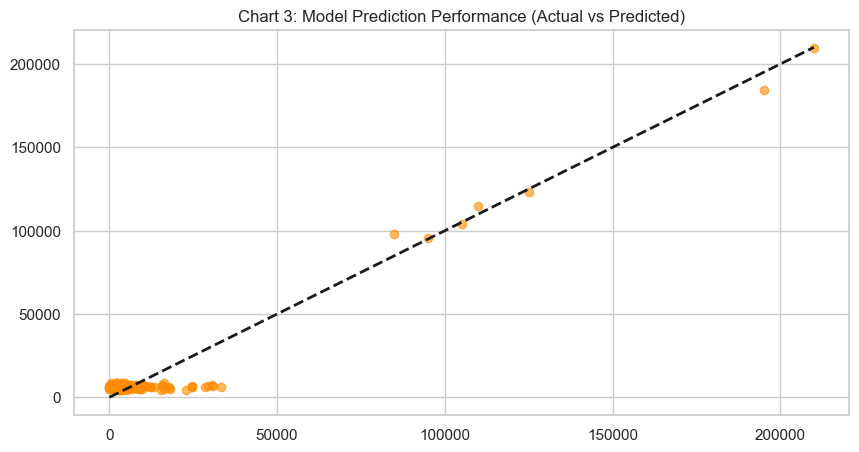

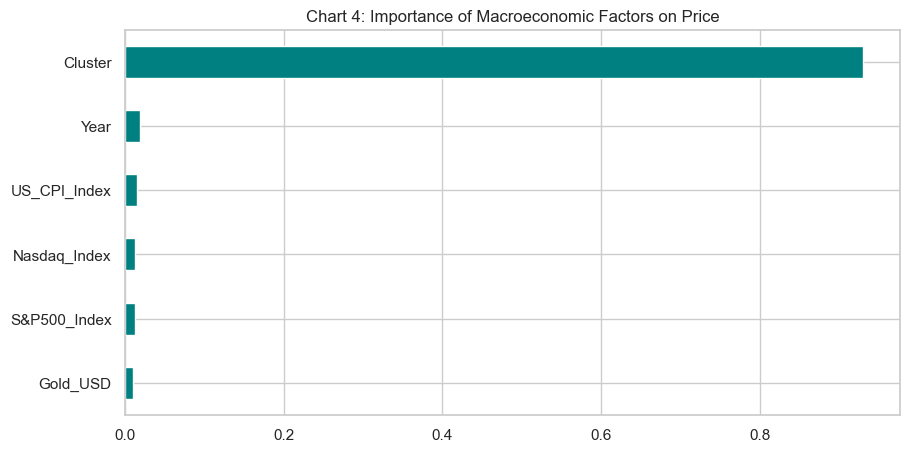

/var/folders/rl/hkspg_7n00n1nf1kmwmml9m00000gn/T/ipykernel_63736/3680664964.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Cluster', y='Value', palette='Set2')


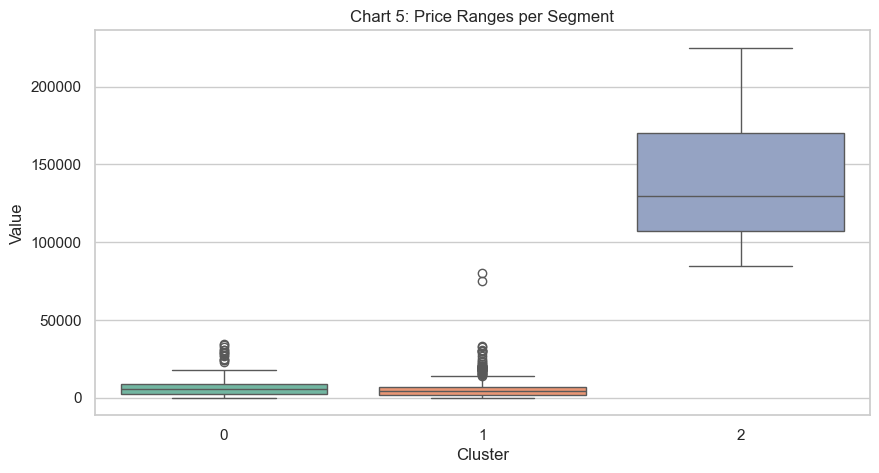

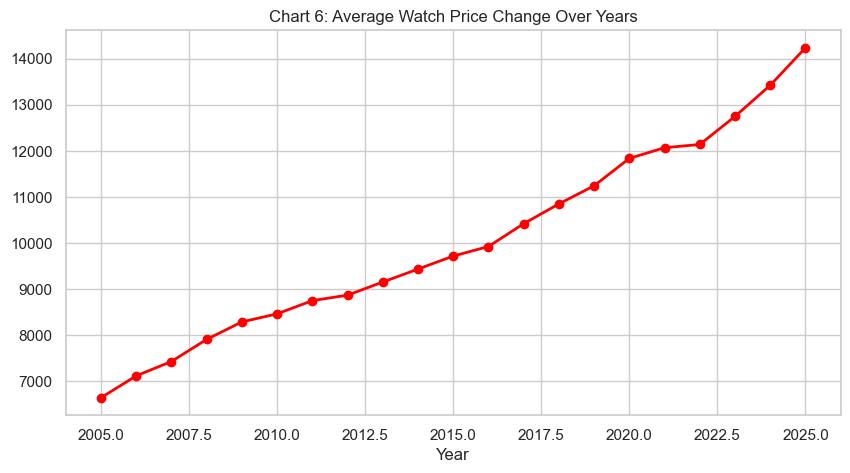

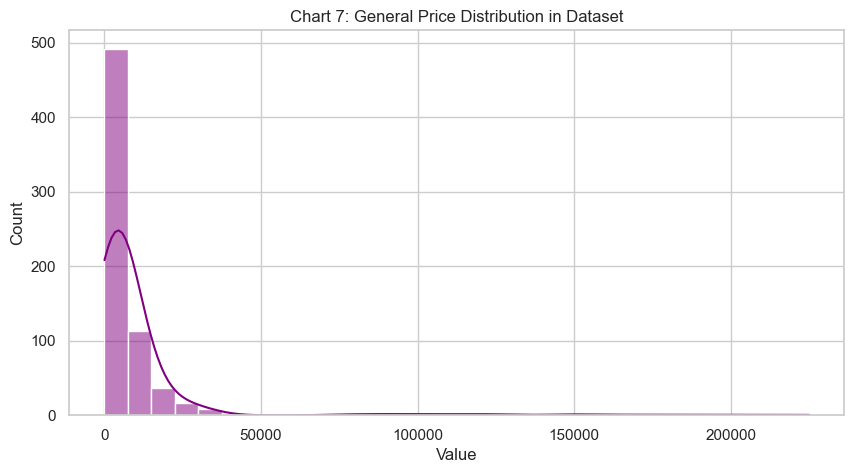

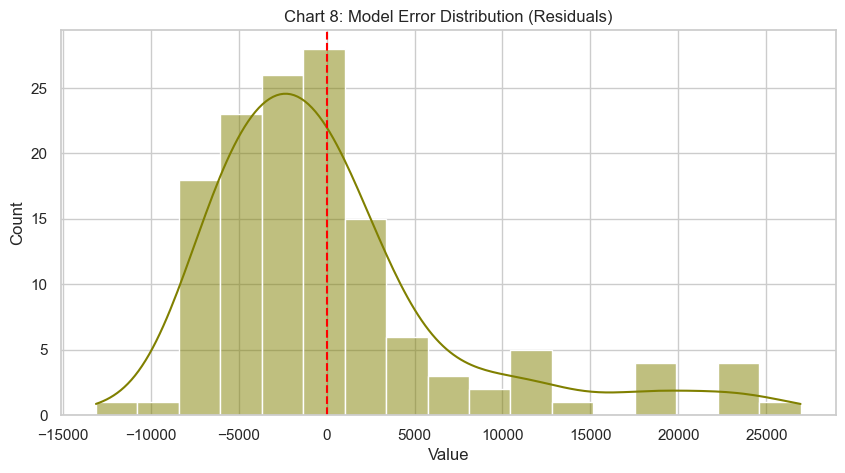

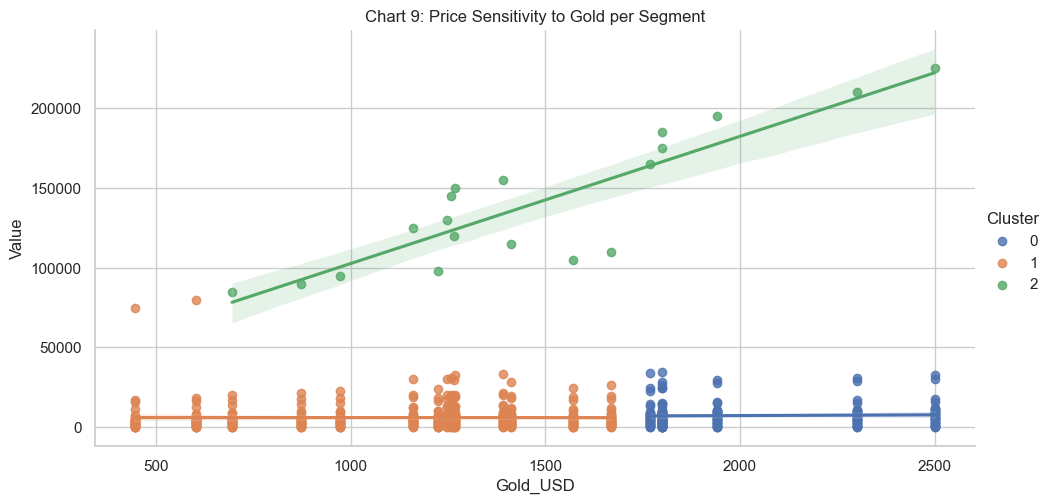


🔮 2027 SCENARIO PREDICTION: 183500.00 USD

⚠️ WATCH MODELS WITH HIGHEST PREDICTION ERROR:
                        Name  Year    Value         Error
46       Richard_Mille_RM011  2006  80000.0  71105.200747
17       Richard_Mille_RM011  2005  75000.0  67465.824297
536  Patek_Philippe_Nautilus  2021  34890.0  28440.765526


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ---------------------------------------------------------
# 1. DATA LOADING AND PREPROCESSING
# ---------------------------------------------------------
# Ensure the file name is exactly as it appears in your folder
file_name = 'df_master_final.csv' 

try:
    df = pd.read_csv(file_name)
    
    # Separating Finance and Watch data for pivoting
    df_finance = df[df['Category'] == 'Finance'].pivot(index='Year', columns='Name', values='Value').reset_index()
    df_watches = df[df['Category'] != 'Finance'].copy()
    
    # Merging datasets based on Year (Master Table)
    df_final = pd.merge(df_watches, df_finance, on='Year', how='inner')
    df_final = df_final.fillna(df_final.mean(numeric_only=True))
    print("✅ Data successfully prepared for analysis.")

    # ---------------------------------------------------------
    # 2. K-MEANS CLUSTERING (Segmentation)
    # ---------------------------------------------------------
    features_cl = ['Value', 'Gold_USD', 'S&P500_Index', 'US_CPI_Index']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_final[features_cl])
    
    # Dividing watches into 3 financial behavior clusters
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_final['Cluster'] = kmeans.fit_predict(X_scaled)

    # ---------------------------------------------------------
    # 3. RANDOM FOREST REGRESSION (Price Prediction)
    # ---------------------------------------------------------
    features_ml = ['Year', 'Gold_USD', 'Nasdaq_Index', 'S&P500_Index', 'US_CPI_Index', 'Cluster']
    X = df_final[features_ml]
    y = df_final['Value']
    
    # Splitting data into Training and Test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    print(f"📊 Model Performance (R2 Score): {r2_score(y_test, y_pred):.4f}")

    # ---------------------------------------------------------
    # 4. VISUALIZATION DASHBOARD (9 CHARTS)
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    
    # Chart 1: K-Means Distribution
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df_final, x='Gold_USD', y='Value', hue='Cluster', palette='viridis', s=100)
    plt.title('Chart 1: Watch Segmentation (K-Means)')
    plt.show()

    # Chart 2: Correlation Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_final[features_ml + ['Value']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Chart 2: Correlation of Financial Variables')
    plt.show()

    # Chart 3: Actual vs Predicted Prices
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test, y_pred, color='darkorange', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.title('Chart 3: Model Prediction Performance (Actual vs Predicted)')
    plt.show()

    # Chart 4: Feature Importance
    importances = pd.Series(rf.feature_importances_, index=features_ml).sort_values(ascending=True)
    plt.figure(figsize=(10, 5))
    importances.plot(kind='barh', color='teal')
    plt.title('Chart 4: Importance of Macroeconomic Factors on Price')
    plt.show()

    # Chart 5: Price Distribution by Cluster (Boxplot)
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_final, x='Cluster', y='Value', palette='Set2')
    plt.title('Chart 5: Price Ranges per Segment')
    plt.show()

    # Chart 6: Average Price Trend Over Time
    plt.figure(figsize=(10, 5))
    df_final.groupby('Year')['Value'].mean().plot(marker='o', color='red', lw=2)
    plt.title('Chart 6: Average Watch Price Change Over Years')
    plt.show()

    # Chart 7: Price Distribution (Histogram)
    plt.figure(figsize=(10, 5))
    sns.histplot(df_final['Value'], bins=30, kde=True, color='purple')
    plt.title('Chart 7: General Price Distribution in Dataset')
    plt.show()

    # Chart 8: Residual Analysis
    plt.figure(figsize=(10, 5))
    sns.histplot(y_test - y_pred, kde=True, color='olive')
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Chart 8: Model Error Distribution (Residuals)')
    plt.show()

    # Chart 9: Gold Sensitivity Analysis
    sns.lmplot(data=df_final, x='Gold_USD', y='Value', hue='Cluster', height=5, aspect=2)
    plt.title('Chart 9: Price Sensitivity to Gold per Segment')
    plt.show()

    # ---------------------------------------------------------
    # 5. FUTURE SCENARIO PREDICTION
    # ---------------------------------------------------------
    future_scenario = pd.DataFrame({
        'Year': [2027], 'Gold_USD': [2850], 'Nasdaq_Index': [19500], 
        'S&P500_Index': [5800], 'US_CPI_Index': [120], 'Cluster': [2]
    })
    future_pred = rf.predict(future_scenario)
    
    print("\n" + "="*40)
    print(f"🔮 2027 SCENARIO PREDICTION: {future_pred[0]:.2f} USD")
    print("="*40)

    # ---------------------------------------------------------
    # 6. MODEL OUTLIER ANALYSIS
    # ---------------------------------------------------------
    df_final['Error'] = np.abs(df_final['Value'] - rf.predict(df_final[features_ml]))
    outliers = df_final.sort_values(by='Error', ascending=False).head(3)
    print("\n⚠️ WATCH MODELS WITH HIGHEST PREDICTION ERROR:")
    print(outliers[['Name', 'Year', 'Value', 'Error']])

except Exception as e:
    print(f"❌ An error occurred: {e}")